# SZ3

[![Citation]](https://doi.org/10.1109/tbdata.2022.3201176)
[![Source]](https://github.com/szcompressor/SZ3)
[![Documentation]](https://szcompressor.org)

[Citation]: https://img.shields.io/badge/citation-grey?style=for-the-badge&logo=doi&logoColor=white
[Source]: https://img.shields.io/badge/source-grey?style=for-the-badge&logo=github&logoColor=white
[Documentation]: https://img.shields.io/badge/documentation-grey?style=for-the-badge&logo=readthedocs&logoColor=white

SZ3 [^sz3] is a prediction-based modular compressor that combines preprocessing, prediction, lossy quantisation, entropy coding, and lossless compression to provide high compression ratios. SZ3 can use several predictors based on Lorenzo prediction, regression, and spline interpolation. It can be configured to bound the pointwise absolute or range-relative error, either or both of them, the peak signal-to-noise ratio, or the $L_2$ norm.

Because of its modular design, SZ3 has been adadpted into many domain-specific compressors, and is continuously being improved with new predictors. A recent listing of many of the specialized compressors can be found in [this survey](https://doi.org/10.1145/3733104).

[^sz3]: Liang, X., Zhao, K., Di, S., Li, S., Underwood, R., Gok, A. M., Tian, J., Deng, J., Calhoun, J. C., Tao, D., Chen, Z., & Cappello, F. (2022). SZ3: A modular framework for composing Prediction-Based Error-Bounded lossy compressors. *IEEE Transactions on Big Data*, 9(2), 485–498. Available from: [doi:10.1109/tbdata.2022.3201176](https://doi.org/10.1109/tbdata.2022.3201176).

In [1]:
from pathlib import Path

import netCDF4
import numpy as np
import xarray as xr

In [2]:
data = Path("data")

In [3]:
import earthkit.plots

from quickplot import quickplot

## Importing the `Sz3` compressor

In [4]:
from numcodecs_wasm_sz3 import Sz3

In [5]:
?Sz3

Init signature:
Sz3(
    eb_mode,
    _version='0.2.0',
    eb_abs=None,
    eb_l2=None,
    eb_psnr=None,
    eb_rel=None,
    predictor='interpolation-lorenzo',
)
Docstring:     
Codec providing compression using SZ3

Parameters
----------
eb_mode : ...
     - "abs-and-rel": Errors are bounded by *both* the absolute and relative error, i.e. by
        whichever bound is stricter
    
     - "abs-or-rel": Errors are bounded by *either* the absolute or relative error, i.e. by
        whichever bound is weaker
    
     - "abs": Absolute error bound
    
     - "rel": Relative error bound
    
     - "psnr": Peak signal to noise ratio error bound
    
     - "l2": Peak L2 norm error bound
_version : ..., optional, default = "0.2.0"
    The codec's encoding format version. Do not provide this parameter explicitly.
eb_abs : ..., optional
    Absolute error bound
eb_l2 : ..., optional
    Peak L2 norm error bound
eb_psnr : ..., optional
    Peak signal to noise ratio error bound
eb_rel : .

### Available Predictors

- `interpolation`: interpolation-only
- `interpolation-lorenzo`: interpolation and first-order Lorenzo (default)
- `regression`: regression-only
- `lorenzo2`: second-order Lorenzo
- `lorenzo2-regression`: second-order Lorenzo and regression
- `lorenzo`: first-order Lorenzo
- `lorenzo-regression`: first-order Lorenzo and regression
- `lorenzo-lorenzo2`: first-order and second-order Lorenzo
- `lorenzo-lorenzo2-regression`: first-order and second-order Lorenzo and regression

The list of supported predictors in `numcodecs-wasm-sz3` can be inspected by providing an invalid predictor name:

In [6]:
try:
    Sz3(predictor="???")
except Exception as err:
    print(err)


 1 | {"predictor":"???"}
   |                   ^ unknown variant `???`, expected one of `interpolation`, `interpolation-lorenzo`, `regression`, `lorenzo2`, `lorenzo2-regression`, `lorenzo`, `lorenzo-regression`, `lorenzo-lorenzo2`, `lorenzo-lorenzo2-regression` at line 1 column 18



Additional predictors and the ability to customize and extend the composition of compressors with new modules are available via SZ3's C++ API [^sz3cpp].

[^sz3cpp]: <https://github.com/szcompressor/SZ3>

## Bounding the pointwise absolute error

SZ3 can bound the absolute error using:

In [7]:
eb_abs = 1.0

Sz3(eb_mode="abs", eb_abs=eb_abs)

Sz3(predictor='interpolation-lorenzo', eb_mode='abs', eb_abs=1.0, _version='0.2.0')

## Bounding the pointwise range-relative error

SZ3 can bound the range-relative error using:

In [8]:
eb_range_rel = 0.1

Sz3(eb_mode="rel", eb_rel=eb_range_rel)

Sz3(predictor='interpolation-lorenzo', eb_mode='rel', eb_rel=0.1, _version='0.2.0')

## Bounding the peak signal-to-noise ratio

SZ3 can bound the PSNR using:

In [9]:
psnr = 50  # dB

Sz3(eb_mode="psnr", eb_psnr=psnr)

Sz3(predictor='interpolation-lorenzo', eb_mode='psnr', eb_psnr=50.0, _version='0.2.0')

## Bounding the pointwise relative error

The easiest way to bound the pointwise relative error with SZ3 is to transform the relative error bound into an absolute error bound [^pwrel] using a metacompressor such as the `pw_rel_compressor_plugin` in LibPressio [^libpressio] or the `numcodecs_pw_ratio.PointwiseRatioErrorBoundedCodec` port:

[^pwrel]: Liang, X., Di, S., Tao, D., Chen, Z., & Cappello, F. (2018). An Efficient Transformation Scheme for Lossy Data Compression with Point-Wise Relative Error Bound. *2018 IEEE International Conference on Cluster Computing (CLUSTER)*, 179–189. Available from: [doi:10.1109/cluster.2018.00036](https://doi.org/10.1109/cluster.2018.00036).

[^libpressio]: Underwood, R., Malvoso, V., Calhoun, J. C., Di, S., & Cappello, F. (2021). Productive and Performant Generic Lossy Data Compression with LibPressio. *2021 7th International Workshop on Data Analysis and Reduction for Big Scientific Data (DRBSD-7)*, 1–10. Available from: [doi:10.1109/drbsd754563.2021.00005](https://doi.org/10.1109/drbsd754563.2021.00005).

In [10]:
from numcodecs_pw_ratio import PointwiseRatioErrorBoundedCodec
from numcodecs_wasm_zstd import Zstd

eb_rel = 0.01

PointwiseRatioErrorBoundedCodec(
    # transform pointwise relative error bound into pointwise ratio error bound
    eb_ratio=1 + eb_rel,
    # mark how the absolute error is configured
    eb_abs_marker="$eb_abs",
    # lossy compressor that will use an absolute error bound
    log_codec={**Sz3(eb_mode="abs", eb_abs=4.2).get_config(), "eb_abs": "$eb_abs"},
    # lossless compressor for compressing the data signs
    sign_codec=Zstd(level=3),
)

PointwiseRatioErrorBoundedCodec(eb_ratio=1.01, eb_abs_marker='$eb_abs', log_codec={'id': 'sz3.rs', 'predictor': 'interpolation-lorenzo', 'eb_mode': 'abs', 'eb_abs': '$eb_abs', '_version': '0.2.0'}, sign_codec=Zstd(level=3, _version='0.1.0'))

The `pw_rel` technique [^pwrel] used by LibPressio was a feature previously included in SZ2 and will be restored in a future version of SZ3.

[^pwrel]: Liang, X., Di, S., Tao, D., Chen, Z., & Cappello, F. (2018). An Efficient Transformation Scheme for Lossy Data Compression with Point-Wise Relative Error Bound. *2018 IEEE International Conference on Cluster Computing (CLUSTER)*, 179–189. Available from: [doi:10.1109/cluster.2018.00036](https://doi.org/10.1109/cluster.2018.00036).

## Preserving Missing Values

NaN values are automatically preserved by SZ3 in version v3.3.2, though this has been broken before [^sz3nan][^climatebenchpress].

[^sz3nan]: <https://github.com/szcompressor/SZ3/pull/91>

[^climatebenchpress]: Reichelt, T., Tyree, J., Klöwer, M., Dueben, P., Lawrence, B. N., Baker, A. H., Faghih-Naini, S., Hoefler, T., & Stier, P. (2026). ClimateBenchPress (v1.0): A Benchmark for Lossy Compression of Climate Data. *EGUsphere [Preprint]*. Available from: [doi:10.5194/egusphere-2026-60](https://doi.org/10.5194/egusphere-2026-60).

## Example

In [11]:
# Load the data
ds = xr.open_dataset(
    data / "hplp" / "hplp_sfc_regridded_t_025deg_steps_228_240.nc",
    engine="netcdf4",
    decode_timedelta=True,
)
da = ds["2t"]

In [12]:
psnr = 50.0  # dB

codec = Sz3(eb_mode="psnr", eb_psnr=psnr)

In [13]:
# encode and decode the data
da_enc = codec.encode(da.values)
da_dec = da.copy(data=codec.decode(da_enc))

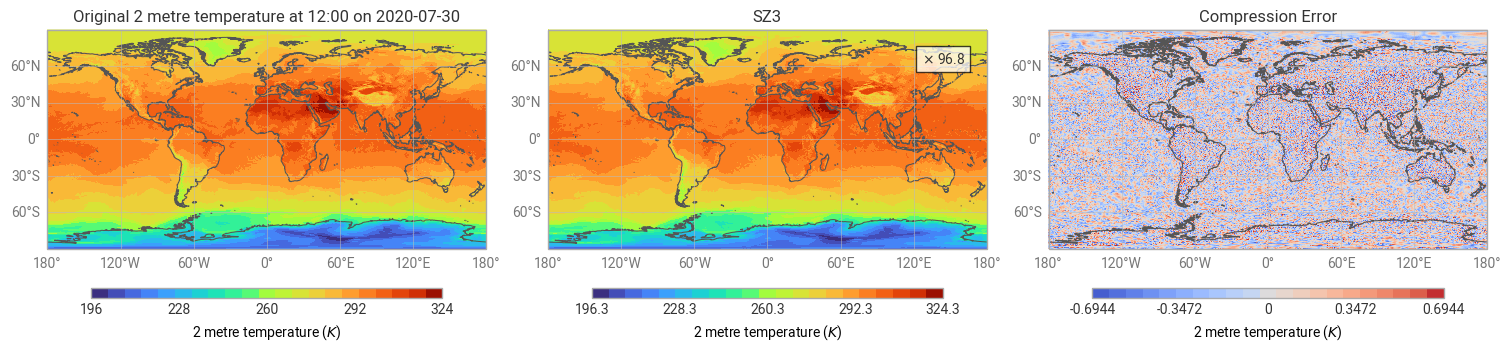

In [14]:
# plot a comparison figure
fig = earthkit.plots.Figure(
    size=(15, 4),
    rows=1,
    columns=3,
)

quickplot(da, fig.add_map(0, 0), title="Original {default_title}")
quickplot(
    da_dec, fig.add_map(0, 1), title="SZ3", cr=da.nbytes / np.array(da_enc).nbytes
)
quickplot(da_dec - da, fig.add_map(0, 2), error=True, title="Compression Error")

fig.show()